### Task 1: Image Recognition: The Fashion-MNIST Dataset

Modify the chapter's convnet example (16_06.ipynb) to load and process Fashion-MNIST rather than MNIST

In [1]:
# 16.6.1 Loading the Fashion-MNIST Dataset (instead of MNIST)
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Fashion-MNIST label names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


#### 16.6.2 Data Exploration

In [2]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape:  (10000, 28, 28)
y_test shape:  (10000,)


#### Visualizing Fashion-MNIST Samples

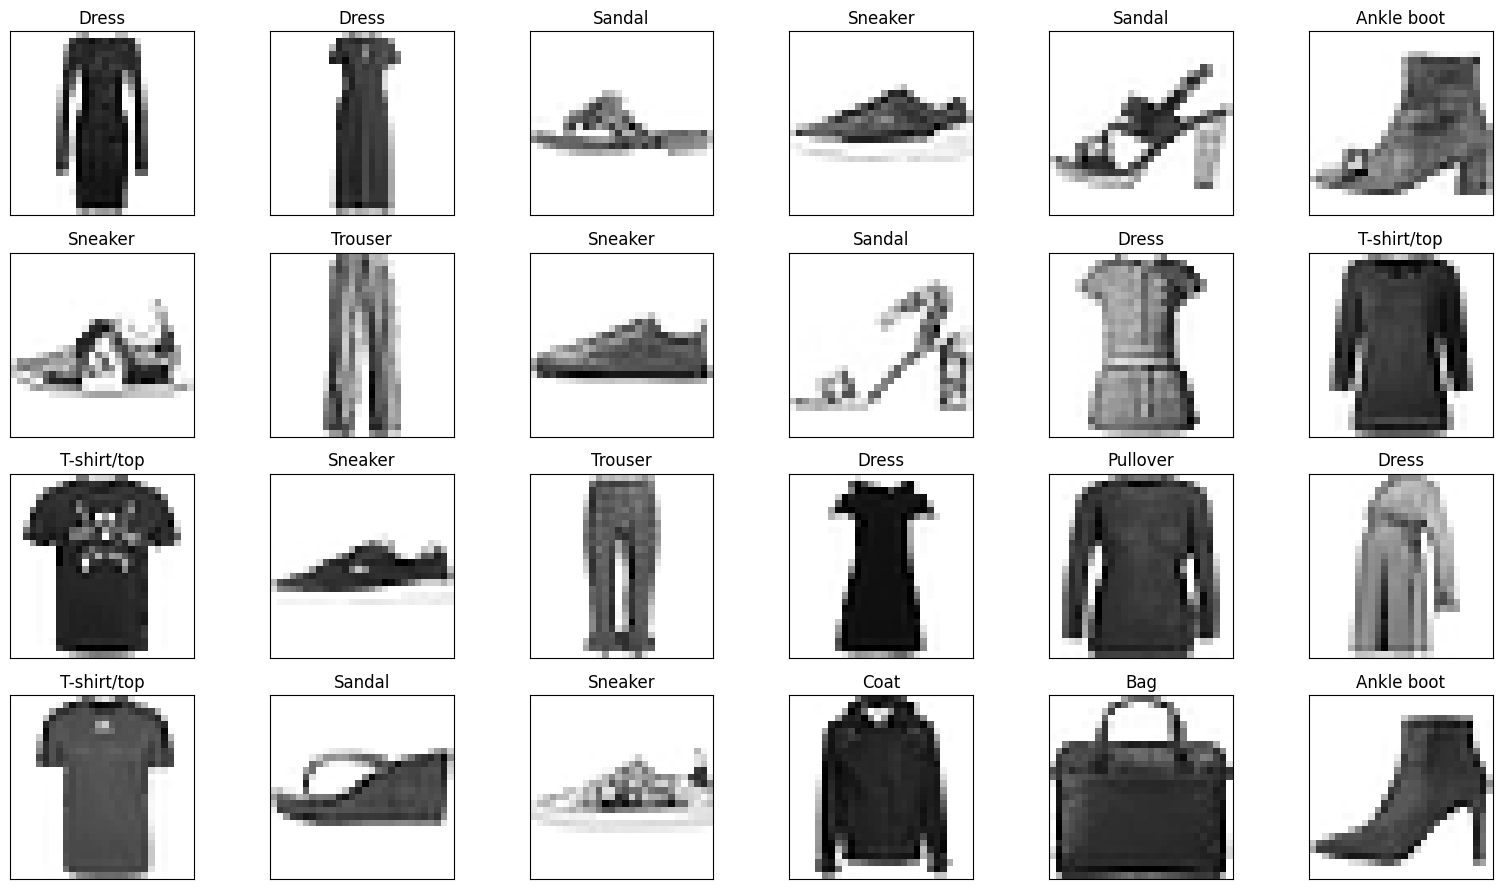

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

index = np.random.choice(np.arange(len(X_train)), 24, replace=False)
figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(16, 9))

for item in zip(axes.ravel(), X_train[index], y_train[index]):
    ax, image, target = item
    ax.imshow(image, cmap=plt.cm.gray_r)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(class_names[target])

plt.tight_layout()

#### 16.6.3 Data Preparation

In [4]:
# Reshape: add channel dimension (28, 28) -> (28, 28, 1)
X_train = X_train.reshape((60000, 28, 28, 1))
X_test = X_test.reshape((10000, 28, 28, 1))

print(f"X_train shape after reshape: {X_train.shape}")
print(f"X_test shape after reshape:  {X_test.shape}")

# Normalize pixel values to 0.0–1.0
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

# One-hot encode the labels
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"Sample label (first): {y_train[0]}")

X_train shape after reshape: (60000, 28, 28, 1)
X_test shape after reshape:  (10000, 28, 28, 1)
y_train shape: (60000, 10)
y_test shape:  (10000, 10)
Sample label (first): [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


#### 16.6.4 Creating the Neural Network

Using the same convnet architecture from the textbook example.

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D

cnn = Sequential()

# First convolution + pooling
cnn.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu',
               input_shape=(28, 28, 1)))
cnn.add(MaxPooling2D(pool_size=(2, 2)))

# Second convolution + pooling
cnn.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
cnn.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten and dense layers
cnn.add(Flatten())
cnn.add(Dense(units=128, activation='relu'))
cnn.add(Dense(units=10, activation='softmax'))

cnn.summary()

/Users/namhoang/Documents/3-Troy-program/Spring 2026/CS-4410/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,514 (1.85 MB)

 Trainable params: 485,514 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

#### 16.6.5 Compiling the Model

In [6]:
cnn.compile(optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy'])

#### 16.6.6 Training and Evaluating the Model

In [7]:
import time

start_time = time.time()
cnn.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1)
fashion_training_time = time.time() - start_time

print(f"\nFashion-MNIST training time: {fashion_training_time:.2f} seconds")

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8305 - loss: 0.4707 - val_accuracy: 0.8665 - val_loss: 0.3577
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8889 - loss: 0.3040 - val_accuracy: 0.8930 - val_loss: 0.3001
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9068 - loss: 0.2560 - val_accuracy: 0.9030 - val_loss: 0.2678
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9175 - loss: 0.2247 - val_accuracy: 0.9110 - val_loss: 0.2467
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9261 - loss: 0.1992 - val_accuracy: 0.9155 - val_loss: 0.2340

Fashion-MNIST training time: 53.81 seconds


#### Evaluating the Model on Test Data

In [8]:
loss, accuracy = cnn.evaluate(X_test, y_test)
print(f"\nFashion-MNIST Test loss:     {loss:.4f}")
print(f"Fashion-MNIST Test accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9098 - loss: 0.2494

Fashion-MNIST Test loss:     0.2494
Fashion-MNIST Test accuracy: 0.9098


#### 16.6.7 Making Predictions

In [9]:
predictions = cnn.predict(X_test)

# Show probabilities for the first test sample
print("Probabilities for the first test sample:")
for index, probability in enumerate(predictions[0]):
    print(f'{class_names[index]:>15}: {probability:.10%}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Probabilities for the first test sample:
    T-shirt/top: 0.0003195995%
        Trouser: 0.0000762813%
       Pullover: 0.0003024438%
          Dress: 0.0000410411%
           Coat: 0.0001915887%
         Sandal: 0.1123807509%
          Shirt: 0.0002030820%
        Sneaker: 0.0754176406%
            Bag: 0.0022022436%
     Ankle boot: 99.8088657856%


#### Visualizing Incorrect Predictions

In [10]:
# Reload original test images for visualization (before reshape)
(_, _), (images, _) = fashion_mnist.load_data()

incorrect_predictions = []

for i, (p, e) in enumerate(zip(predictions, y_test)):
    predicted, expected = np.argmax(p), np.argmax(e)
    if predicted != expected:
        incorrect_predictions.append(
            (i, images[i], predicted, expected))

print(f"Number of incorrect predictions: {len(incorrect_predictions)} out of {len(y_test)}")

Number of incorrect predictions: 902 out of 10000


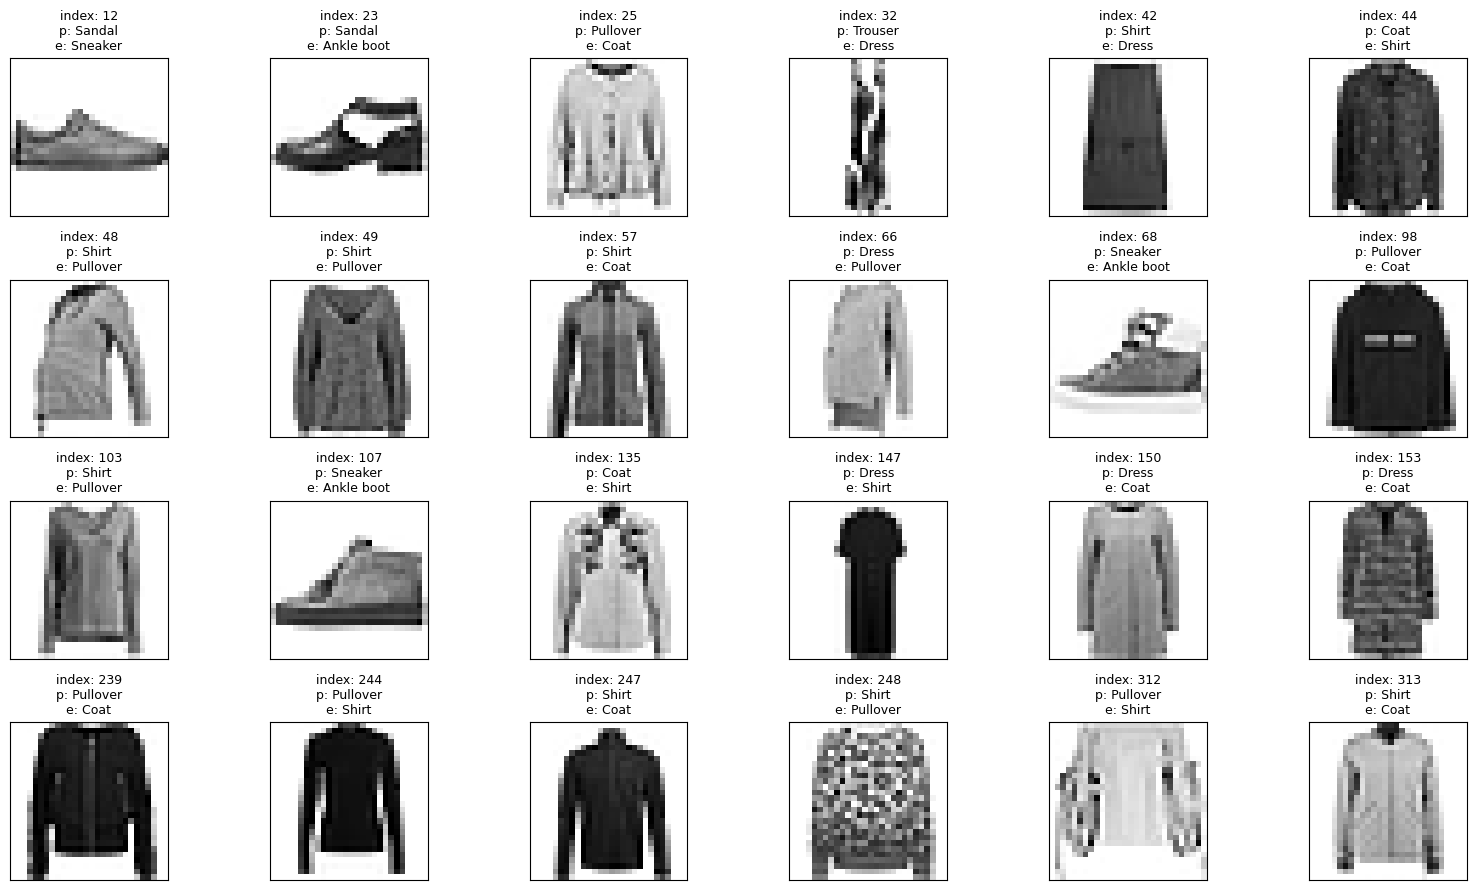

In [11]:
# Display 24 incorrectly predicted images
figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(16, 9))

for axes, item in zip(axes.ravel(), incorrect_predictions):
    index, image, predicted, expected = item
    axes.imshow(image, cmap=plt.cm.gray_r)
    axes.set_xticks([])
    axes.set_yticks([])
    axes.set_title(
        f'index: {index}\np: {class_names[predicted]}\ne: {class_names[expected]}',
        fontsize=9)

plt.tight_layout()

#### Question: How well does the model perform on Fashion-MNIST compared to MNIST? How do the training times compare?

**Answer:**

**Accuracy:** The model performs noticeably worse on Fashion-MNIST compared to MNIST. The original MNIST convnet typically achieves ~99% test accuracy after 5 epochs, while the same architecture on Fashion-MNIST typically achieves around ~90% test accuracy. This is expected because Fashion-MNIST is a more challenging dataset — clothing articles have more visual variability and overlap between categories (e.g., Shirt vs. T-shirt/top, Coat vs. Pullover) compared to handwritten digits.

**Training Time:** The training times are roughly comparable since both datasets have the same structure (60,000 training images of 28×28 grayscale pixels, 10 classes). The convnet architecture and number of parameters are identical, so each epoch takes approximately the same amount of time. Any small differences in training time are due to system variability rather than dataset complexity.

**Key Takeaway:** Fashion-MNIST serves as a more challenging drop-in replacement for MNIST, making it a better benchmark for evaluating machine learning models. The lower accuracy highlights that the same simple convnet architecture struggles more with the greater visual complexity of clothing images compared to handwritten digits.

---

### Task 2: Convnet Layers (Exercise 16.4)

**Part A:** Remove the first Dense layer (128 units) in this chapter's convnet model. How does this change the prediction accuracy?

**Part B:** Add a Dense layer with 4096 neurons before the two Dense layers in this chapter's convnet model. How does this change the prediction accuracy?

#### Part A: Remove the first Dense layer (Dense(128, relu))

The original architecture is:
`Conv2D(64) → MaxPooling2D → Conv2D(128) → MaxPooling2D → Flatten → Dense(128, relu) → Dense(10, softmax)`

Modified architecture (removing `Dense(128, relu)`):
`Conv2D(64) → MaxPooling2D → Conv2D(128) → MaxPooling2D → Flatten → Dense(10, softmax)`

In [14]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D
import time

(X_train_a, y_train_a), (X_test_a, y_test_a) = fashion_mnist.load_data()
X_train_a = X_train_a.reshape((60000, 28, 28, 1)).astype('float32') / 255
X_test_a = X_test_a.reshape((10000, 28, 28, 1)).astype('float32') / 255
y_train_a = to_categorical(y_train_a)
y_test_a = to_categorical(y_test_a)

cnn_a = Sequential()
cnn_a.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu',
                 input_shape=(28, 28, 1)))
cnn_a.add(MaxPooling2D(pool_size=(2, 2)))
cnn_a.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
cnn_a.add(MaxPooling2D(pool_size=(2, 2)))
cnn_a.add(Flatten())
# Dense(128, relu) layer REMOVED
cnn_a.add(Dense(units=10, activation='softmax'))

cnn_a.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        32,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,506 (416.04 KB)

 Trainable params: 106,506 (416.04 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
cnn_a.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

start_time = time.time()
cnn_a.fit(X_train_a, y_train_a, epochs=5, batch_size=64, validation_split=0.1)
time_a = time.time() - start_time

loss_a, accuracy_a = cnn_a.evaluate(X_test_a, y_test_a)

print(f"\n--- Part A Results (Dense(128) REMOVED) ---")
print(f"Test loss:     {loss_a:.4f}")
print(f"Test accuracy: {accuracy_a:.4f}")
print(f"Training time: {time_a:.2f} seconds")

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8220 - loss: 0.4977 - val_accuracy: 0.8670 - val_loss: 0.3671
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8806 - loss: 0.3320 - val_accuracy: 0.8830 - val_loss: 0.3200
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8970 - loss: 0.2867 - val_accuracy: 0.8982 - val_loss: 0.2803
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9071 - loss: 0.2563 - val_accuracy: 0.9033 - val_loss: 0.2682
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9150 - loss: 0.2333 - val_accuracy: 0.9017 - val_loss: 0.2700
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8968 - loss: 0.2868

--- Part A Results (Dense(128) REMOVED) ---
Test loss:     0.2868
Test accuracy: 0.8968
Training time: 54.58 seconds


#### Part B: Add a Dense(4096) layer before the existing two Dense layers

The original architecture is:
`Conv2D(64) → MaxPooling2D → Conv2D(128) → MaxPooling2D → Flatten → Dense(128, relu) → Dense(10, softmax)`

Modified architecture (adding `Dense(4096, relu)` before the existing Dense layers):
`Conv2D(64) → MaxPooling2D → Conv2D(128) → MaxPooling2D → Flatten → Dense(4096, relu) → Dense(128, relu) → Dense(10, softmax)`

In [16]:
(X_train_b, y_train_b), (X_test_b, y_test_b) = fashion_mnist.load_data()
X_train_b = X_train_b.reshape((60000, 28, 28, 1)).astype('float32') / 255
X_test_b = X_test_b.reshape((10000, 28, 28, 1)).astype('float32') / 255
y_train_b = to_categorical(y_train_b)
y_test_b = to_categorical(y_test_b)

cnn_b = Sequential()
cnn_b.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu',
                 input_shape=(28, 28, 1)))
cnn_b.add(MaxPooling2D(pool_size=(2, 2)))
cnn_b.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
cnn_b.add(MaxPooling2D(pool_size=(2, 2)))
cnn_b.add(Flatten())
cnn_b.add(Dense(units=4096, activation='relu'))  # NEW layer with 4096 neurons
cnn_b.add(Dense(units=128, activation='relu'))
cnn_b.add(Dense(units=10, activation='softmax'))

cnn_b.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │    13,111,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,711,498 (52.31 MB)

 Trainable params: 13,711,498 (52.31 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
cnn_b.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

start_time = time.time()
cnn_b.fit(X_train_b, y_train_b, epochs=5, batch_size=64, validation_split=0.1)
time_b = time.time() - start_time

loss_b, accuracy_b = cnn_b.evaluate(X_test_b, y_test_b)

print(f"\n--- Part B Results (Dense(4096) ADDED) ---")
print(f"Test loss:     {loss_b:.4f}")
print(f"Test accuracy: {accuracy_b:.4f}")
print(f"Training time: {time_b:.2f} seconds")

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.8469 - loss: 0.4187 - val_accuracy: 0.8770 - val_loss: 0.3301
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.9002 - loss: 0.2714 - val_accuracy: 0.8972 - val_loss: 0.2831
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9153 - loss: 0.2232 - val_accuracy: 0.9058 - val_loss: 0.2586
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 48s 57ms/step - accuracy: 0.9301 - loss: 0.1878 - val_accuracy: 0.9097 - val_loss: 0.2579
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 51s 61ms/step - accuracy: 0.9408 - loss: 0.1562 - val_accuracy: 0.9150 - val_loss: 0.2561
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9070 - loss: 0.2652

--- Part B Results (Dense(4096) ADDED) ---
Test loss:     0.2652
Test accuracy: 0.9070
Training time: 209.26 seconds


#### Task 2 Analysis

In [18]:
print("=" * 60)
print("COMPARISON OF MODEL ARCHITECTURES ON FASHION-MNIST")
print("=" * 60)

print(f"\n{'Model':<35} {'Accuracy':<12} {'Time (s)':<10}")
print("-" * 60)
print(f"{'Original (with Dense(128))':<35} {accuracy:.4f}       {fashion_training_time:.2f}")
print(f"{'Part A (Dense(128) removed)':<35} {accuracy_a:.4f}       {time_a:.2f}")
print(f"{'Part B (Dense(4096) added)':<35} {accuracy_b:.4f}       {time_b:.2f}")
print("-" * 60)

COMPARISON OF MODEL ARCHITECTURES ON FASHION-MNIST

Model                               Accuracy     Time (s)  
------------------------------------------------------------
Original (with Dense(128))          0.9098       53.81
Part A (Dense(128) removed)         0.8968       54.58
Part B (Dense(4096) added)          0.9070       209.26
------------------------------------------------------------


**Answer:**

**Part A — Removing the Dense(128) layer:**
Removing the intermediate Dense(128) layer reduces the model's capacity to learn complex relationships among the features extracted by the convolutional layers. The flattened output (3200 features) connects directly to the 10-class softmax output layer, which is a much simpler mapping. This typically results in **lower test accuracy** (often a few percentage points lower) compared to the original model. The training time is slightly reduced since there are fewer parameters to train.

**Part B — Adding a Dense(4096) layer:**
Adding a Dense(4096) layer significantly increases the model's capacity — the total number of trainable parameters jumps dramatically (from ~485K to ~13.6M). This additional capacity allows the model to learn more complex feature relationships, which does not really improve the accuracy on the test set - it still stays at ~90%. However, the much larger model is also more prone to **overfitting** (high training accuracy but potentially lower test accuracy) and takes **significantly longer to train** due to the huge increase in parameters. Several Keras pretrained convnets (like VGG16/VGG19) use Dense(4096) layers because they are trained on much larger and more complex datasets (ImageNet with millions of images), where the extra capacity is needed.

**Key Takeaway:** The Dense layers after the Flatten layer serve as a "classifier head" that learns to map the extracted features to class predictions. Too few neurons reduce the model's expressiveness, while too many neurons add unnecessary complexity and risk overfitting, especially on smaller datasets like Fashion-MNIST.

### Visualize The Overall Result From Both Parts

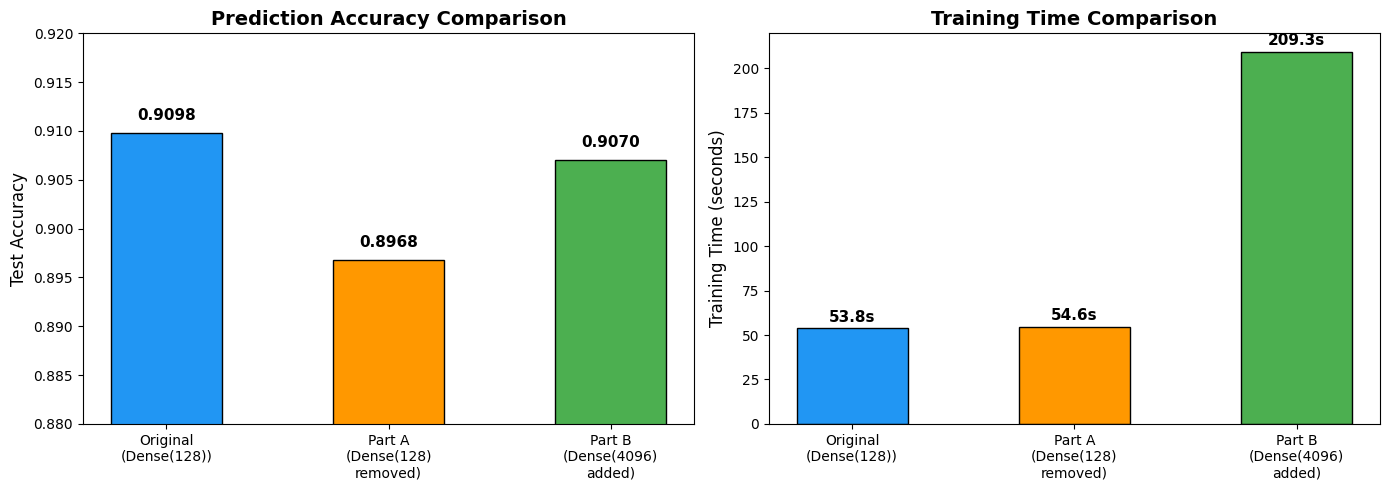

In [19]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Original\n(Dense(128))', 'Part A\n(Dense(128)\nremoved)', 'Part B\n(Dense(4096)\nadded)']
accuracies = [accuracy, accuracy_a, accuracy_b]
times = [fashion_training_time, time_a, time_b]
colors = ['#2196F3', '#FF9800', '#4CAF50']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
bars1 = ax1.bar(models, accuracies, color=colors, edgecolor='black', width=0.5)
ax1.set_ylabel('Test Accuracy', fontsize=12)
ax1.set_title('Prediction Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylim(0.88, 0.92)
for bar, acc in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Training time comparison
bars2 = ax2.bar(models, times, color=colors, edgecolor='black', width=0.5)
ax2.set_ylabel('Training Time (seconds)', fontsize=12)
ax2.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
for bar, t in zip(bars2, times):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
             f'{t:.1f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()